In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import adjusted_mutual_info_score
from clustereval import parsimony_score, homogeneity_score
import matplotlib.pyplot as plt
plt.style.use('clustereval.mplstyle')

In [2]:
X, y = fetch_openml('mnist_784', return_X_y=True, as_frame=False, parser='auto')
X = X / 255.0

# Subsample the data for faster computation
prng = np.random.RandomState(42)
idx = prng.choice(len(X), 2000, replace=False)
X_sub = X[idx]
y_sub = y[idx]
print(f"Data shape: {X_sub.shape}")

# Reduce dimensionality
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_sub)
print(f"PCA shape: {X_pca.shape}")


Data shape: (2000, 784)
PCA shape: (2000, 50)


In [3]:
import warnings
warnings.filterwarnings('ignore')

eps_values = np.arange(0.2, 10.0, 0.2)
min_samples = 1

results = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_pca)
    
    if min_samples > 1:
        noise_labels = labels[labels == -1]
        labels[labels == -1] = -1*np.arange(len(noise_labels))  # Assign unique labels to noise points

    h = homogeneity_score(y_sub, labels)
    p = parsimony_score(y_sub, labels)
    ami = adjusted_mutual_info_score(y_sub, labels)
    n_clusters = len(set(labels))
    noise_ratio = np.sum(labels == -1) / len(labels)
    
    results.append({
        'eps': eps,
        'homogeneity': h,
        'parsimony': p,
        'ami': ami,
        'n_clusters': n_clusters,
        'noise_ratio': noise_ratio
    })

df_dbscan = pd.DataFrame(results)

In [4]:
k_values = sorted(set(np.logspace(np.log10(2), np.log10(2000), 100).astype(int)))
kmeans_results = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_pca)
    
    h = homogeneity_score(y_sub, labels)
    p = parsimony_score(y_sub, labels)
    ami = adjusted_mutual_info_score(y_sub, labels)
    
    kmeans_results.append({
        'k': k,
        'homogeneity': h,
        'parsimony': p,
        'ami': ami,
        'algorithm': 'KMeans'
    })

df_kmeans = pd.DataFrame(kmeans_results)

In [5]:
# Pareto frontier helper function

def get_pareto_frontier(Xs, Ys, maxX=True, maxY=True):
    values = sorted([[Xs[i], Ys[i]] for i in range(len(Xs))], reverse=maxX)
    p_front = [values[0]]    
    for pair in values[1:]:
        if maxY: 
            if pair[1] >= p_front[-1][1]:
                p_front.append(pair)
        else:
            if pair[1] <= p_front[-1][1]:
                p_front.append(pair)
    p_frontX = [pair[0] for pair in p_front]
    p_frontY = [pair[1] for pair in p_front]
    return p_frontX, p_frontY

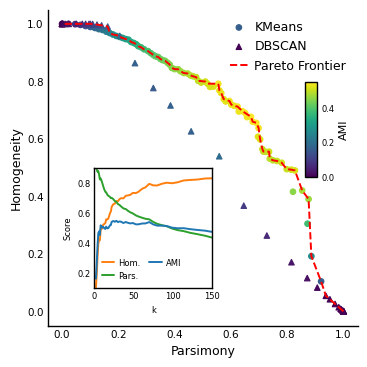

In [ ]:
fig, ax = plt.subplots(figsize=(3.5, 3.5))

df_combined = pd.concat([df_dbscan, df_kmeans], ignore_index=True)

cmin = 0
cmax = df_combined['ami'].max()


sc = ax.scatter(df_kmeans['parsimony'], df_kmeans['homogeneity'], 
                 c=df_kmeans['ami'], cmap='viridis', marker='o', label='KMeans',
                 vmin=cmin, vmax=cmax)

sc2 = ax.scatter(df_dbscan['parsimony'], df_dbscan['homogeneity'], 
                c=df_dbscan['ami'], cmap='viridis', marker='^', label='DBSCAN',
                vmin=cmin, vmax=cmax)


ax.set_xlabel('Parsimony')
ax.set_ylabel('Homogeneity')

px, py = get_pareto_frontier(df_combined['parsimony'].values, df_combined['homogeneity'].values)
ax.plot(px, py, color='red', linestyle='--', label='Pareto Frontier')

ax.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0))

# Create inset axes for the colorbar positioned right below the upper right legend
cax = ax.inset_axes([0.83, 0.47, 0.04, 0.3])
cb = plt.colorbar(sc, cax=cax, label='AMI', orientation='vertical')
cb.ax.tick_params(labelsize=6)
cb.set_label('AMI', size=8)

# Plot inset axes for KMeans metrics vs k
axins = ax.inset_axes([0.15, 0.12, 0.38, 0.38])

df_kmeans_sorted = df_kmeans.sort_values(by='k')
axins.plot(df_kmeans_sorted['k'], df_kmeans_sorted['homogeneity'], label='Hom.', color='C1')
axins.plot(df_kmeans_sorted['k'], df_kmeans_sorted['parsimony'], label='Pars.', color='C2')
axins.plot(df_kmeans_sorted['k'], df_kmeans_sorted['ami'], label='AMI', color='C0')

axins.set_xlabel('k', fontsize=6)
axins.set_ylabel('Score', fontsize=6)
axins.tick_params(axis='both', which='major', labelsize=6)
axins.set_xlim(0, 150)
axins.set_ylim(0.1, 0.9)
axins.legend(fontsize=6, ncol=2)

# Show all spines for the inset axes
for spine in axins.spines.values():
    spine.set_visible(True)

fig.tight_layout(pad=0.1)

In [7]:
df_kmeans.sort_values(by='ami', ascending=False).head(10)

,k,homogeneity,parsimony,ami,algorithm
22,28,0.676666,0.671366,0.545604,KMeans
20,24,0.655533,0.690466,0.544365,KMeans
24,32,0.689965,0.651068,0.541456,KMeans
25,34,0.696127,0.641446,0.539430,KMeans
21,26,0.659550,0.677588,0.539161,KMeans
19,22,0.637607,0.698550,0.538233,KMeans
27,40,0.712121,0.623848,0.537503,KMeans
35,70,0.791682,0.555363,0.537116,KMeans
23,30,0.675637,0.657431,0.536896,KMeans
28,43,0.714995,0.611466,0.531862,KMeans


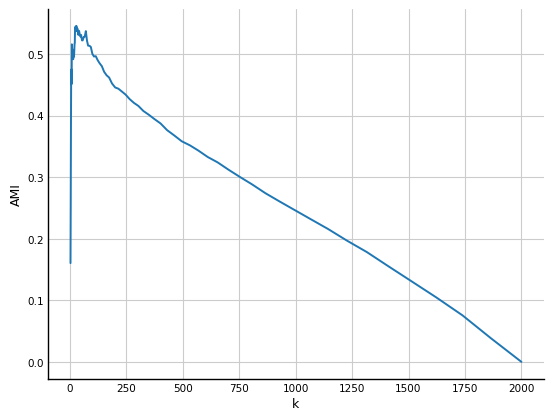

In [8]:
df_kmeans_sorted = df_kmeans.sort_values(by='k')
plt.plot(df_kmeans_sorted['k'], df_kmeans_sorted['ami'], label='AMI', color='C0')
plt.grid()
plt.ylabel('AMI')
plt.xlabel('k');

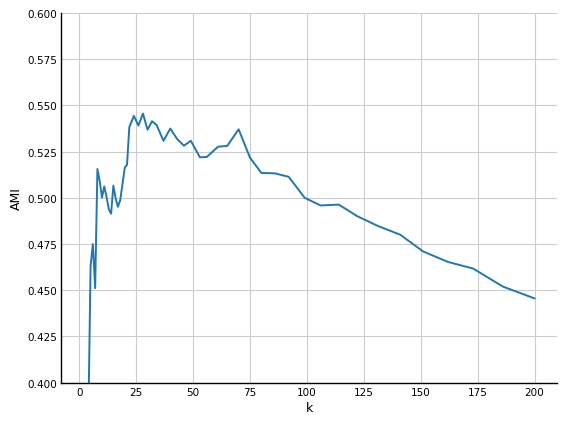

In [9]:
df_kmeans_sorted = df_kmeans.sort_values(by='k')
df_kmeans_sorted = df_kmeans_sorted[df_kmeans_sorted['k'] <= 210]
plt.plot(df_kmeans_sorted['k'], df_kmeans_sorted['ami'], label='AMI', color='C0')
plt.ylim(0.4, 0.6)
plt.grid()
plt.ylabel('AMI')
plt.xlabel('k');